In [1]:
%load_ext autoreload
%autoreload 2

### Environment Set Up

In [2]:
# Set the number of threads to use for running ML models
import os

os.environ["OMP_NUM_THREADS"] = str(os.cpu_count())

#### Importing Libraries
We begin by importing the necessary libraries for data analysis, visualization, and model building

In [3]:
# Import Necessary Packages and Module
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import shap

# Custom package - for loading, preprocessing, model development and evaluation
from utility.utility_functions import load_data,cormat,preprocess_data,fairness_check,load_model
from utility.model_training import train_and_evaluate_model
from utility.evaluation import evaluate_performance
from utility.cross_validate import model_tuning

c:\Users\Aderoju\Desktop\Python Project\diabetes-test-app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Set Chart fontsize, number of columns for pandas DataFrame
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 4000)
plt.style.use('ggplot')
mpl.rcParams['font.size'] = 10

### Loading the Dataset

Here, we will load the dataset into python environment, explore the dataset to understand its structure and identify any anomalies.

In [6]:
# specify the path to the dataset
data_path = r"raw/diabetes_data.csv"
df = load_data(data_path)

In [7]:
# Preliminary data check
df.head(1)

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryDiabetes,GestationalDiabetes,PolycysticOvarySyndrome,PreviousPreDiabetes,Hypertension,SystolicBP,DiastolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,AntihypertensiveMedications,Statins,AntidiabeticMedications,FrequentUrination,ExcessiveThirst,UnexplainedWeightLoss,FatigueLevels,BlurredVision,SlowHealingSores,TinglingHandsFeet,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,44,Male,African American,High,Primary,32.985284,Yes,4.499365,2.443385,4.898831,4.049885,Yes,Yes,No,No,No,93,73,163.687162,9.283631,2.665607,28.190147,254.27067,86.993627,70.801469,190.335834,No,No,Yes,No,No,No,9.534169,No,No,Yes,73.765109,No,No,No,1.782724,4.48698,7.211349,1,Confidential


### Data Cleaning & Exploratory Data Analysis (EDA)

Under this section, we will try to understand the various columns in the dataset, to enable us determine methods for handling these columns for cleaning, and further analysis. 

In [5]:
#Indicate the target column
target_column='Diagnosis'

In [8]:
# Show The First 5 Rows of the Dataset
print(df.head())

   PatientID  Age  Gender         Ethnicity SocioeconomicStatus  \
0          1   44    Male  African American                High   
1          2   51  Female         Caucasian              Middle   
2          3   89  Female         Caucasian              Middle   
3          4   21  Female  African American              Middle   
4          5   27  Female         Caucasian              Middle   

  EducationLevel        BMI Smoking  AlcoholConsumption  PhysicalActivity  \
0        Primary  32.985284     Yes            4.499365          2.443385   
1      Secondary  39.916764      No            1.578919          8.301264   
2         Higher  19.782251      No            1.177301          6.103395   
3      Secondary  32.376881     Yes            1.714621          8.645465   
4         Higher  16.808600      No           15.462549          4.629383   

   DietQuality  SleepQuality FamilyHistoryDiabetes GestationalDiabetes  \
0     4.898831      4.049885                   Yes          

In [9]:
# Show The Last 5 Rows of the Dataset
print(df.tail())

      PatientID  Age  Gender         Ethnicity SocioeconomicStatus  \
1874       1875   37    Male         Caucasian                High   
1875       1876   80  Female         Caucasian                High   
1876       1877   38  Female         Caucasian                 Low   
1877       1878   43    Male  African American                High   
1878       1879   85  Female         Caucasian                High   

           EducationLevel        BMI Smoking  AlcoholConsumption  \
1874            Secondary  20.811137      No           10.946207   
1875            Secondary  27.694312      No           16.067905   
1876            Secondary  35.640824      No            4.865124   
1877  No formal education  32.423016      No            6.362936   
1878            Secondary  33.145119      No           13.854861   

      PhysicalActivity  DietQuality  SleepQuality FamilyHistoryDiabetes  \
1874          3.217636     8.338196      8.703430                    No   
1875          7.1073

In [10]:
# Show The Dimension of the Dataset
print(df.shape)

(1879, 46)


In [11]:
# Show the general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1879 entries, 0 to 1878
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1879 non-null   int64  
 1   Age                            1879 non-null   int64  
 2   Gender                         1879 non-null   object 
 3   Ethnicity                      1879 non-null   object 
 4   SocioeconomicStatus            1879 non-null   object 
 5   EducationLevel                 1879 non-null   object 
 6   BMI                            1879 non-null   float64
 7   Smoking                        1879 non-null   object 
 8   AlcoholConsumption             1879 non-null   float64
 9   PhysicalActivity               1879 non-null   float64
 10  DietQuality                    1879 non-null   float64
 11  SleepQuality                   1879 non-null   float64
 12  FamilyHistoryDiabetes          1879 non-null   o

In [12]:
# Number of Missing Data By Column
print(df.isna().sum())

PatientID                        0
Age                              0
Gender                           0
Ethnicity                        0
SocioeconomicStatus              0
EducationLevel                   0
BMI                              0
Smoking                          0
AlcoholConsumption               0
PhysicalActivity                 0
DietQuality                      0
SleepQuality                     0
FamilyHistoryDiabetes            0
GestationalDiabetes              0
PolycysticOvarySyndrome          0
PreviousPreDiabetes              0
Hypertension                     0
SystolicBP                       0
DiastolicBP                      0
FastingBloodSugar                0
HbA1c                            0
SerumCreatinine                  0
BUNLevels                        0
CholesterolTotal                 0
CholesterolLDL                   0
CholesterolHDL                   0
CholesterolTriglycerides         0
AntihypertensiveMedications      0
Statins             

In [13]:
# Number of Duplicated Rows
print(df.duplicated().sum())

0


In [14]:
# Number of Unique Values By column
print(df.nunique())

PatientID                        1879
Age                                71
Gender                              2
Ethnicity                           4
SocioeconomicStatus                 3
EducationLevel                      4
BMI                              1879
Smoking                             2
AlcoholConsumption               1879
PhysicalActivity                 1879
DietQuality                      1879
SleepQuality                     1879
FamilyHistoryDiabetes               2
GestationalDiabetes                 2
PolycysticOvarySyndrome             2
PreviousPreDiabetes                 2
Hypertension                        2
SystolicBP                         90
DiastolicBP                        60
FastingBloodSugar                1879
HbA1c                            1879
SerumCreatinine                  1879
BUNLevels                        1879
CholesterolTotal                 1879
CholesterolLDL                   1879
CholesterolHDL                   1879
CholesterolT

In [15]:
# Descriptive statistics for the numeric features 
print(df.describe(include=['float','int']))

         PatientID          Age          BMI  AlcoholConsumption  \
count  1879.000000  1879.000000  1879.000000         1879.000000   
mean    940.000000    55.043108    27.687601           10.096587   
std     542.564896    20.515839     7.190975            5.914216   
min       1.000000    20.000000    15.025898            0.000928   
25%     470.500000    38.000000    21.469981            4.789725   
50%     940.000000    55.000000    27.722988           10.173865   
75%    1409.500000    73.000000    33.856460           15.285359   
max    1879.000000    90.000000    39.998811           19.996231   

       PhysicalActivity  DietQuality  SleepQuality   SystolicBP  DiastolicBP  \
count       1879.000000  1879.000000   1879.000000  1879.000000  1879.000000   
mean           5.200790     4.895801      7.021328   134.050559    89.863757   
std            2.857012     2.867144      1.729469    25.613830    17.328086   
min            0.004089     0.000885      4.004336    90.000000    

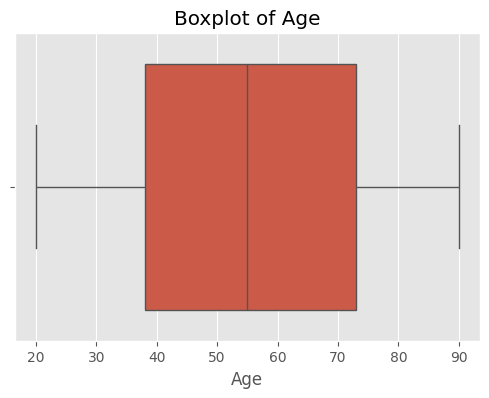

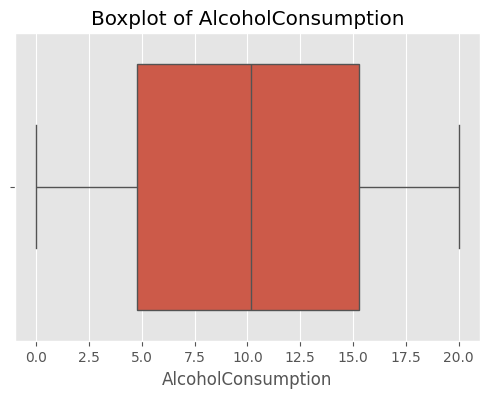

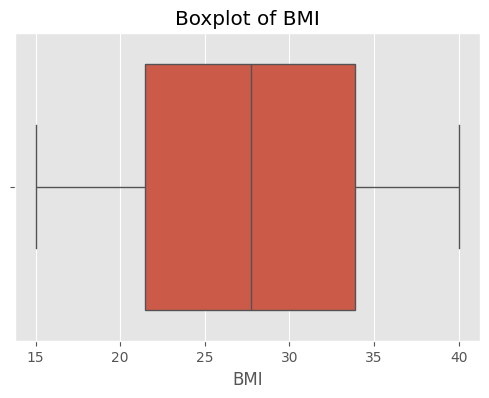

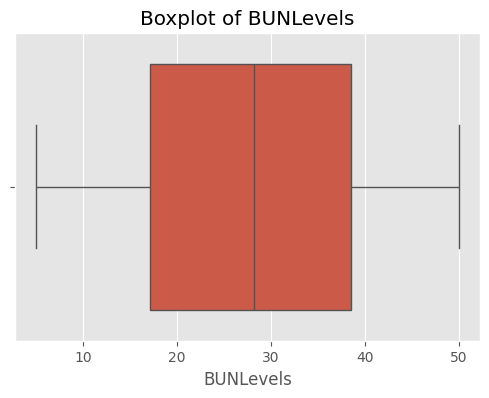

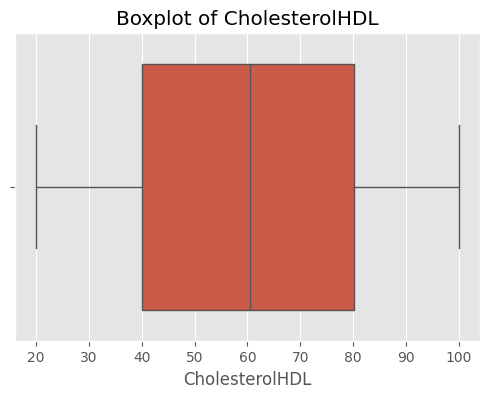

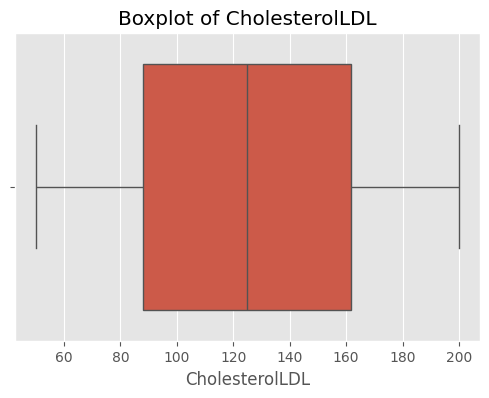

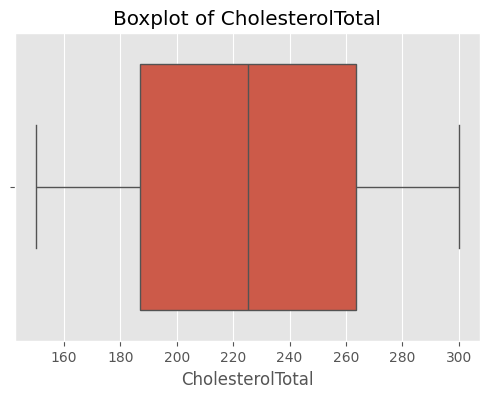

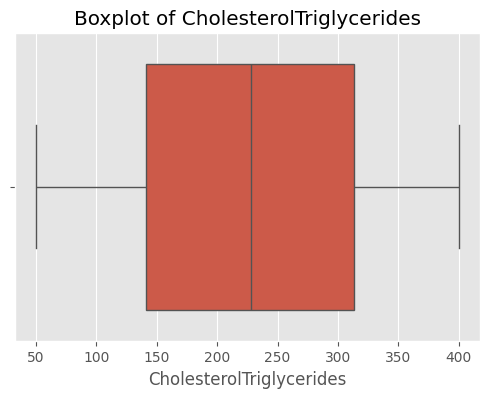

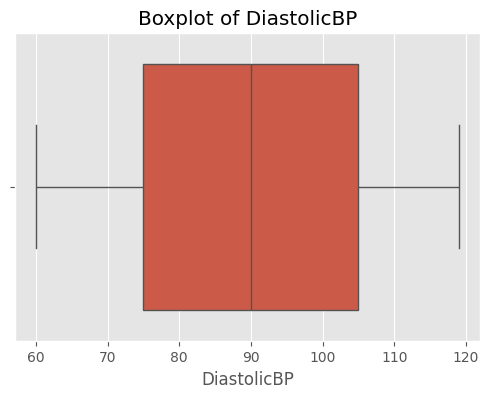

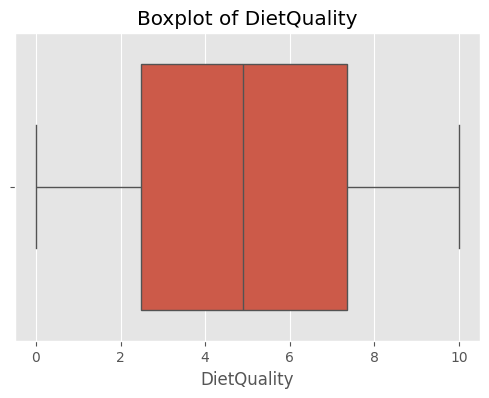

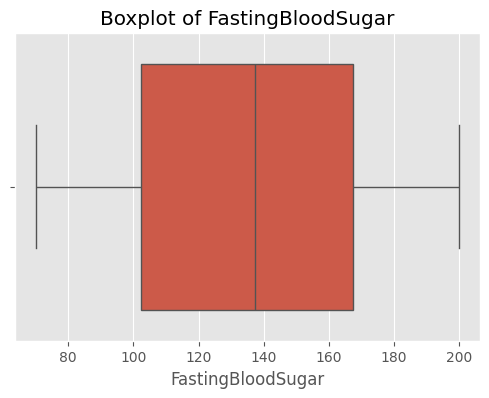

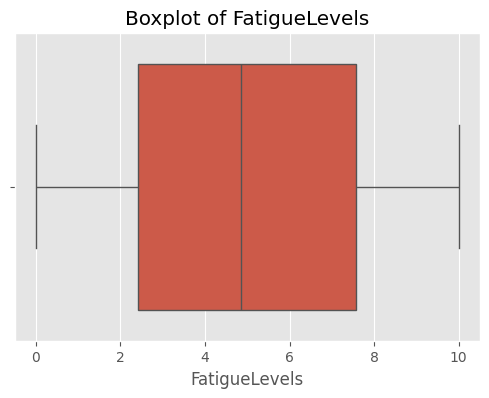

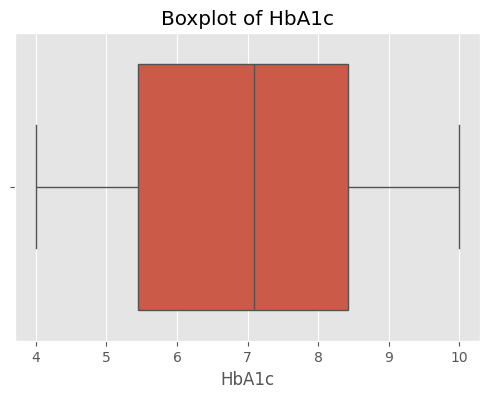

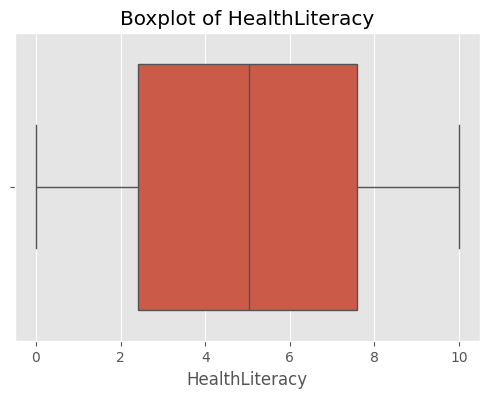

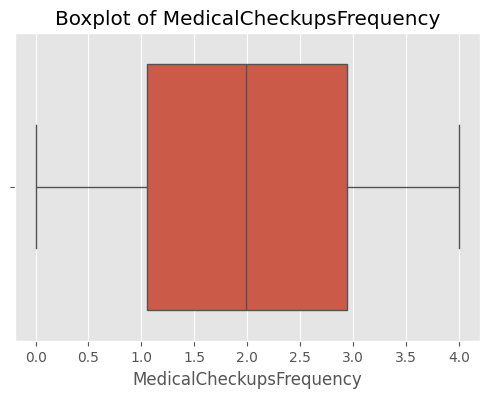

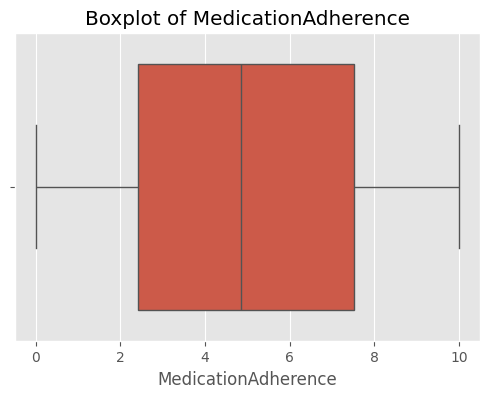

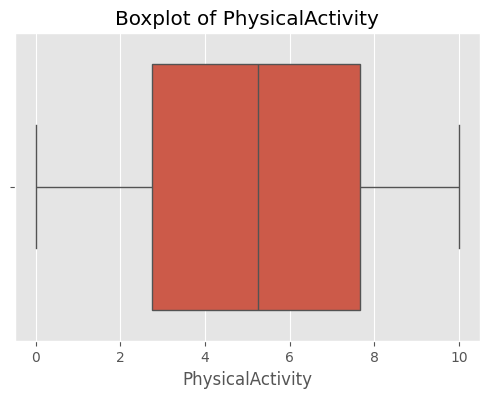

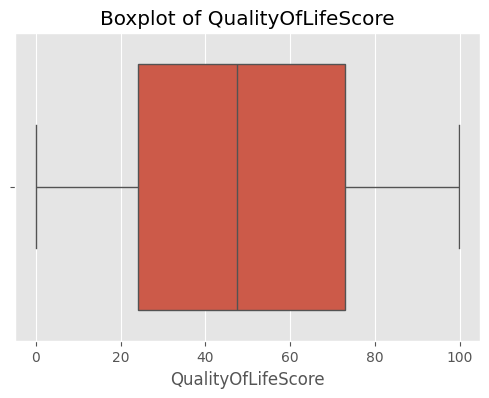

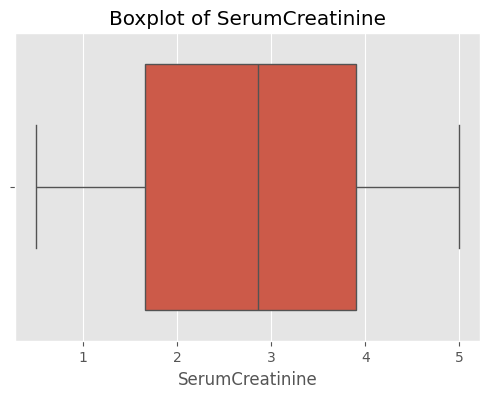

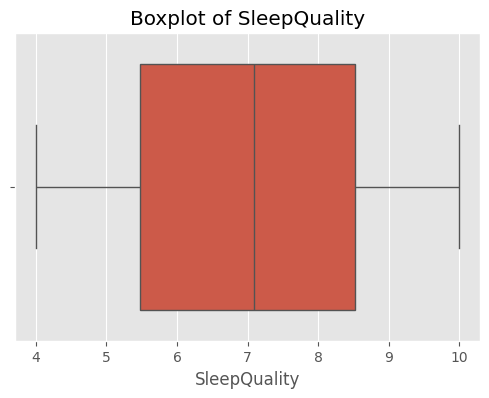

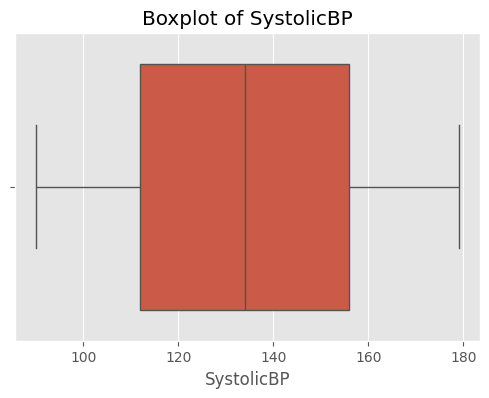

In [16]:
# Checking for outliers in the numeric features
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.difference([target_column,'PatientID'])
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

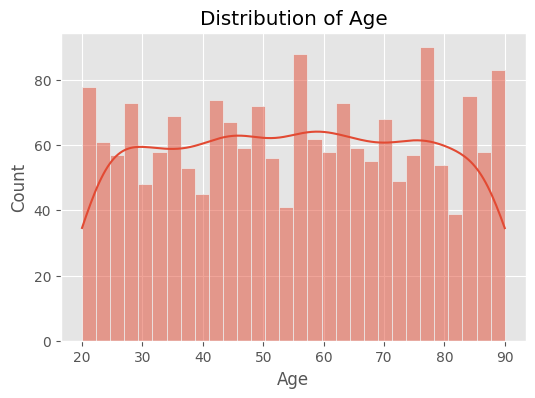

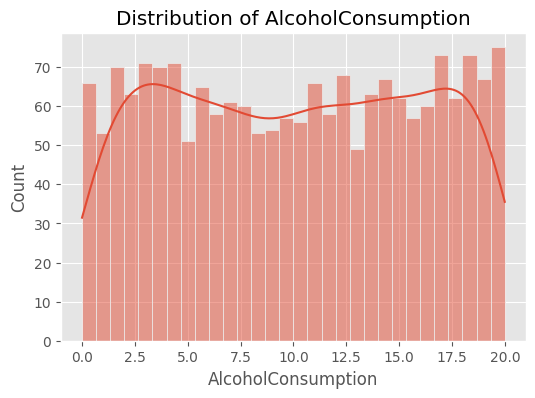

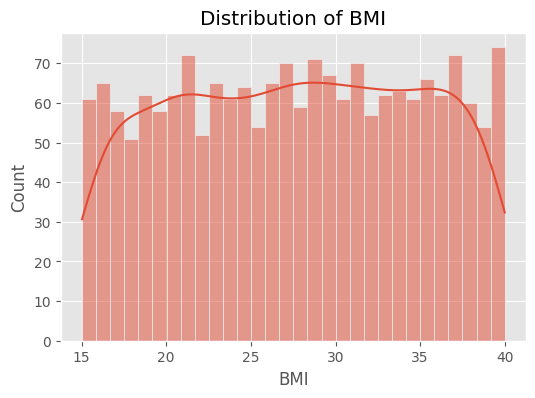

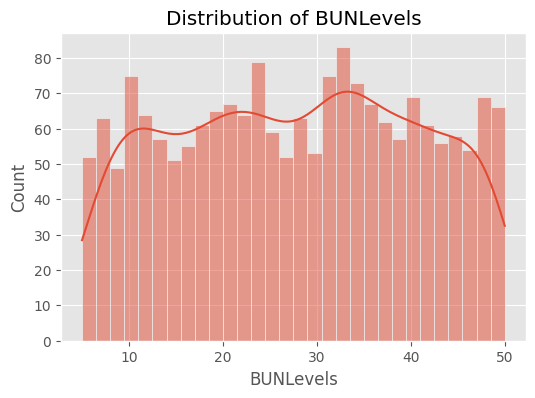

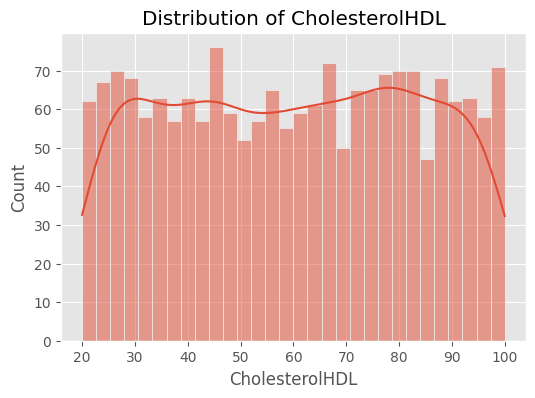

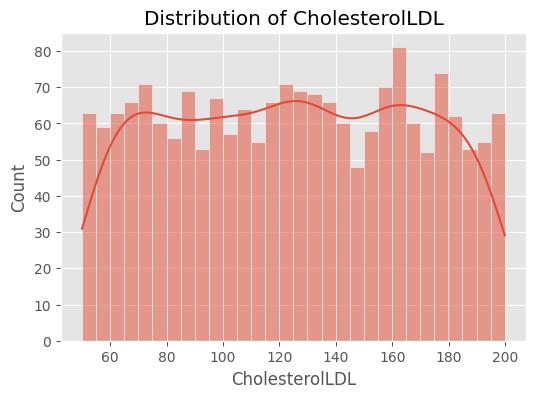

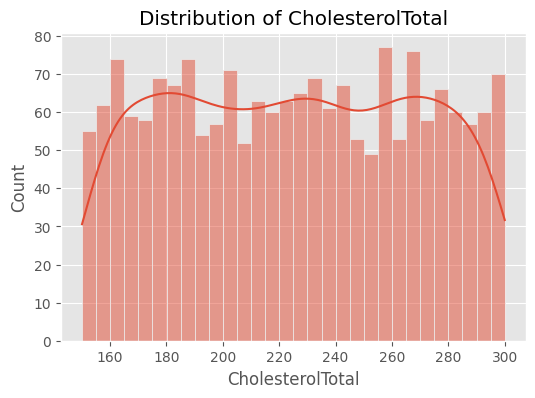

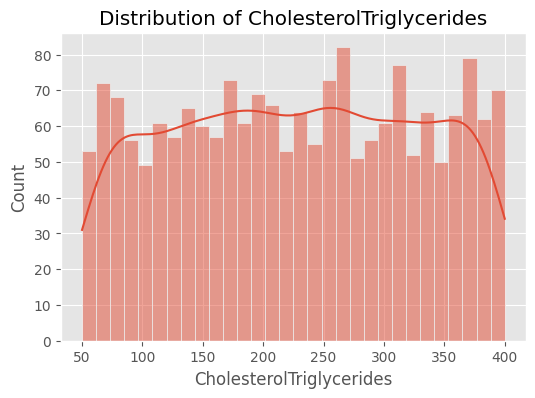

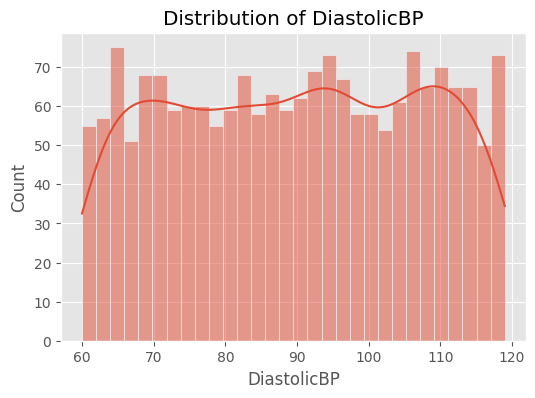

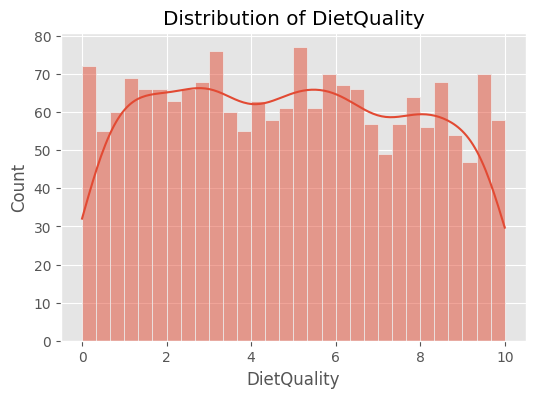

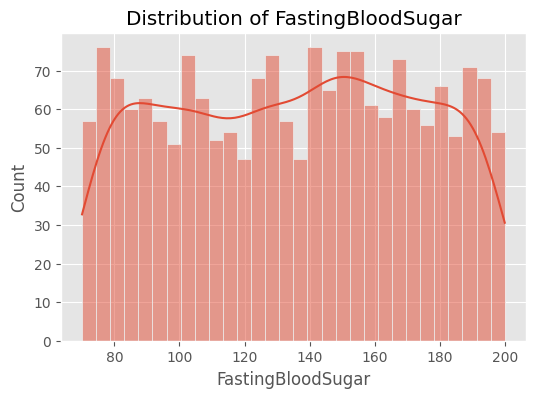

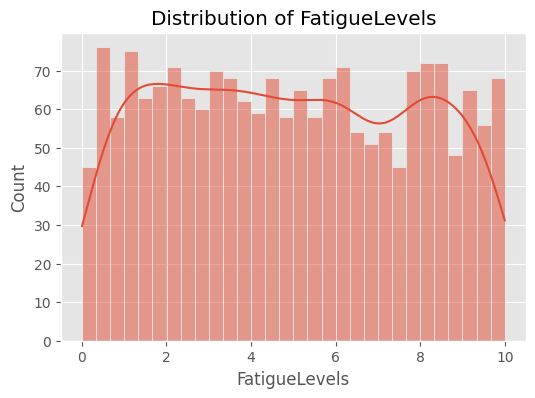

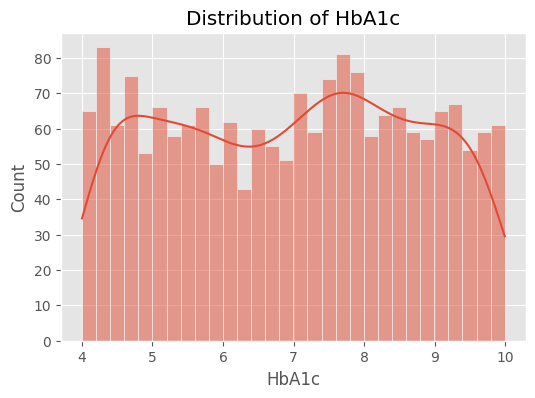

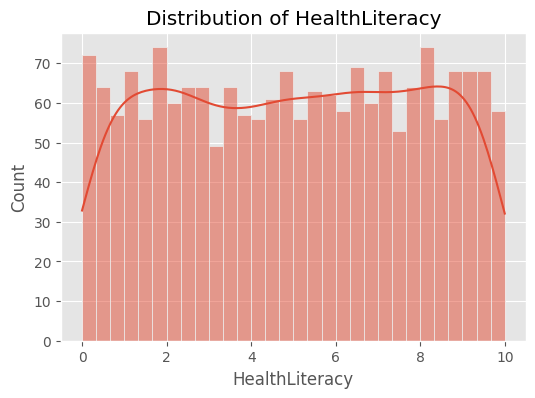

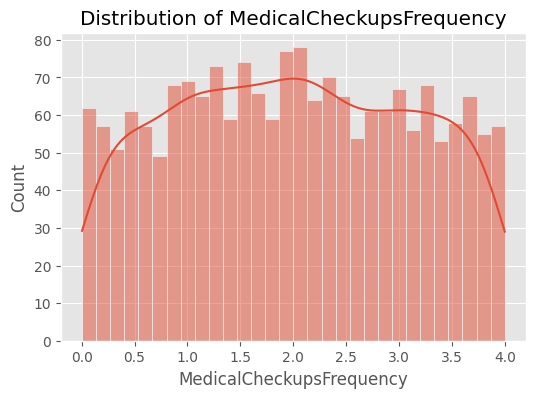

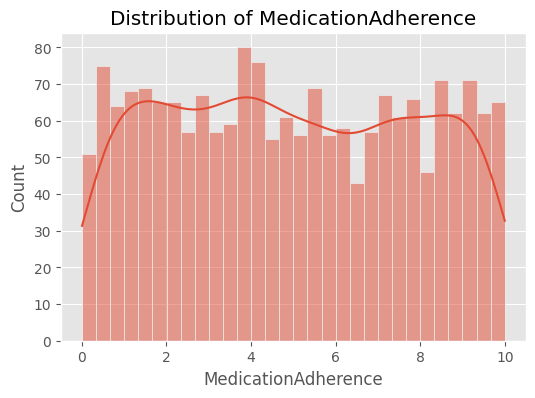

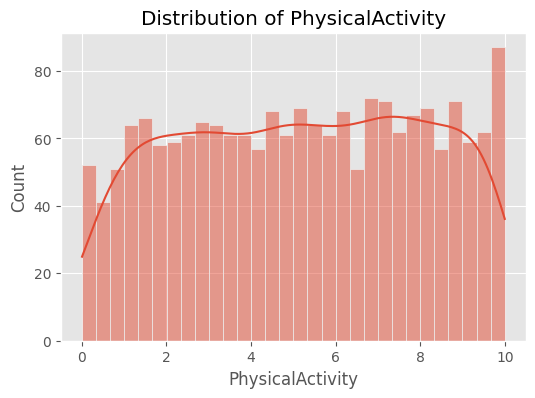

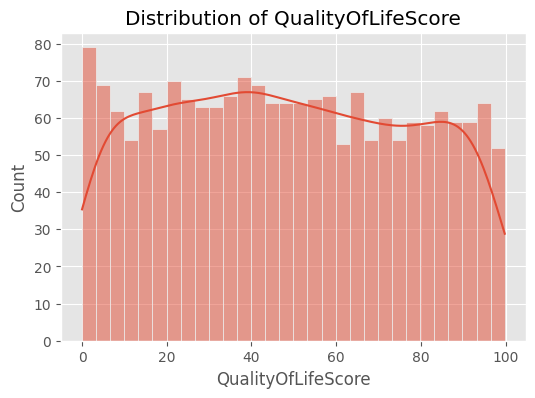

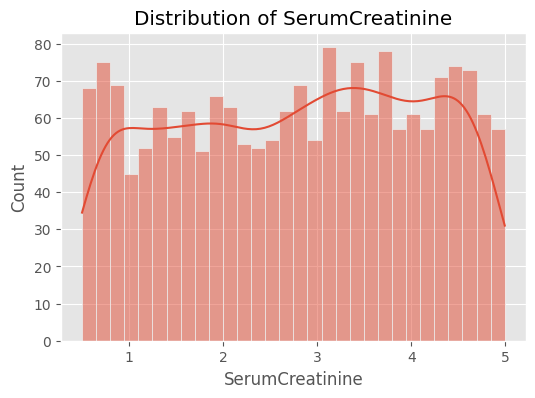

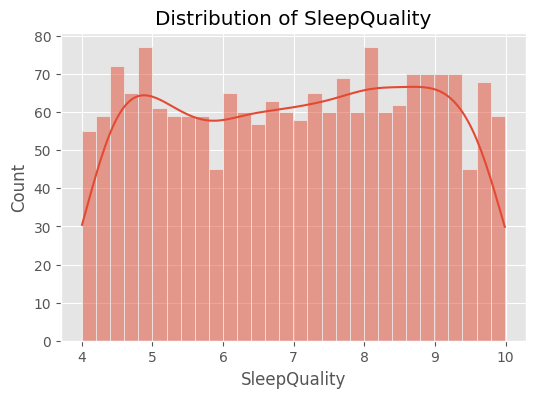

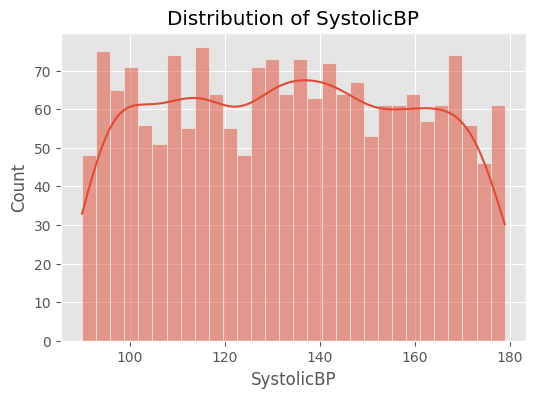

In [17]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [27]:
df[numeric_columns].kurt()

Age                        -1.179022
AlcoholConsumption         -1.256988
BMI                        -1.176119
BUNLevels                  -1.152205
CholesterolHDL             -1.224336
CholesterolLDL             -1.185796
CholesterolTotal           -1.212164
CholesterolTriglycerides   -1.180699
DiastolicBP                -1.205858
DietQuality                -1.174744
FastingBloodSugar          -1.197476
FatigueLevels              -1.209304
HbA1c                      -1.211294
HealthLiteracy             -1.231449
MedicalCheckupsFrequency   -1.122361
MedicationAdherence        -1.222132
PhysicalActivity           -1.180986
QualityOfLifeScore         -1.171322
SerumCreatinine            -1.204418
SleepQuality               -1.225332
SystolicBP                 -1.167035
dtype: float64

In [26]:
df[numeric_columns].skew()

Age                        -0.004160
AlcoholConsumption         -0.005187
BMI                        -0.030875
BUNLevels                  -0.026392
CholesterolHDL             -0.013239
CholesterolLDL             -0.005499
CholesterolTotal            0.010649
CholesterolTriglycerides   -0.017044
DiastolicBP                -0.024546
DietQuality                 0.049484
FastingBloodSugar          -0.038826
FatigueLevels               0.056646
HbA1c                      -0.031005
HealthLiteracy             -0.018141
MedicalCheckupsFrequency    0.015934
MedicationAdherence         0.047363
PhysicalActivity           -0.050839
QualityOfLifeScore          0.052337
SerumCreatinine            -0.085168
SleepQuality               -0.042458
SystolicBP                  0.015089
dtype: float64

<Axes: ylabel='count'>

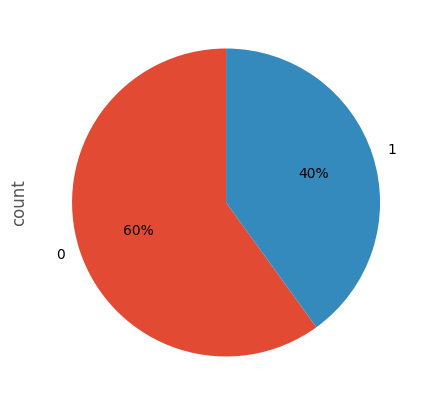

In [25]:
df[target_column].value_counts().plot.pie(
        autopct="%1.0f%%",   # show percentages
        figsize=(5,5),    
        startangle=90       # rotate for better readability
    )

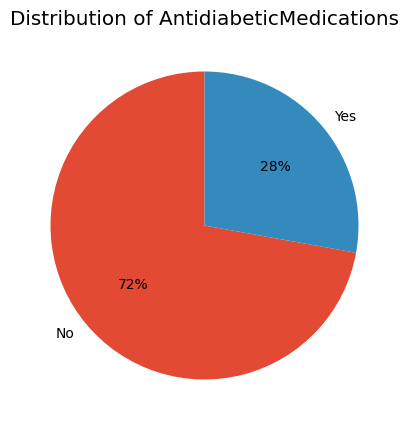

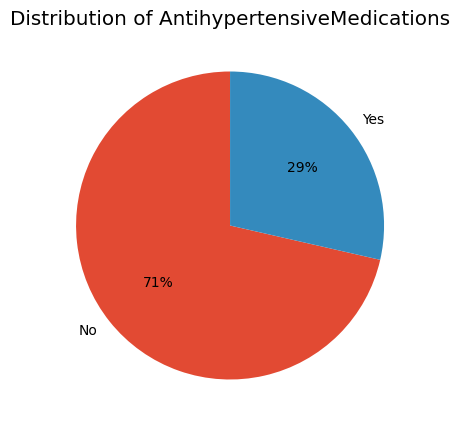

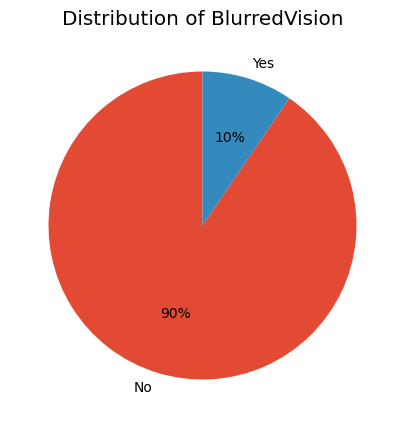

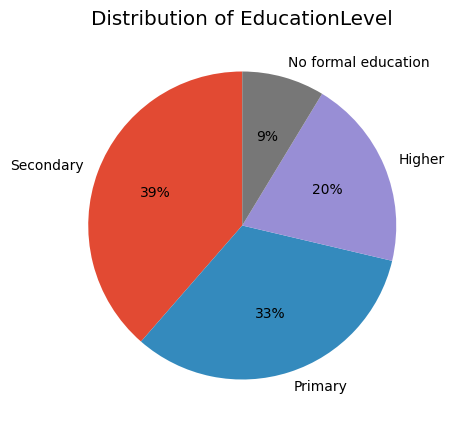

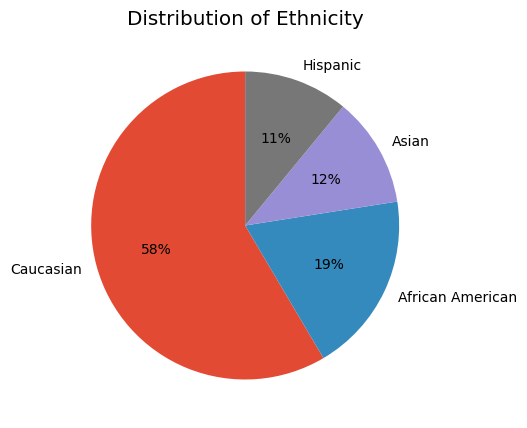

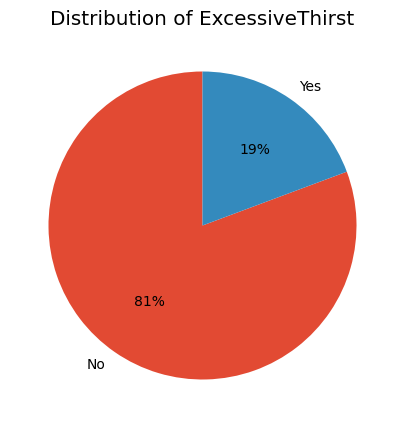

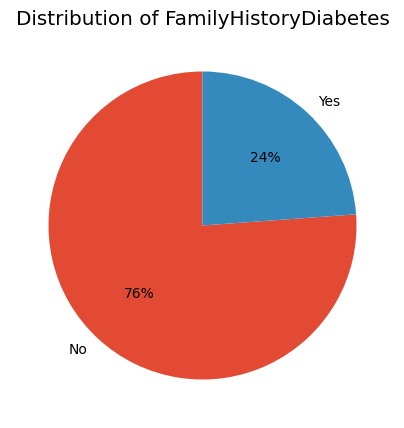

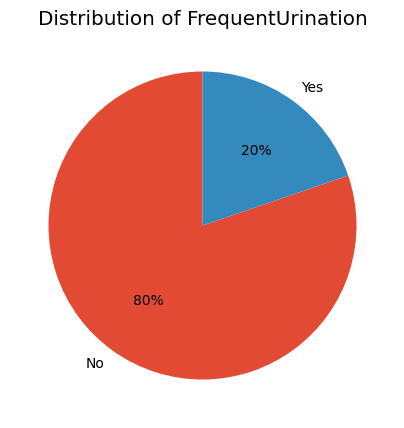

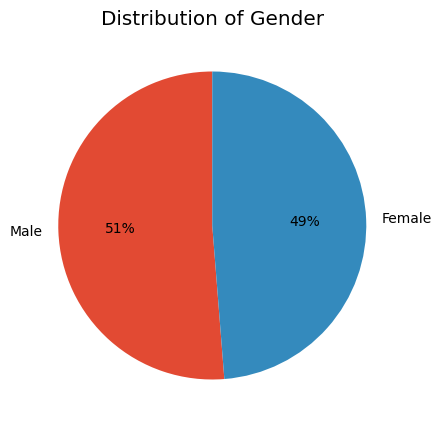

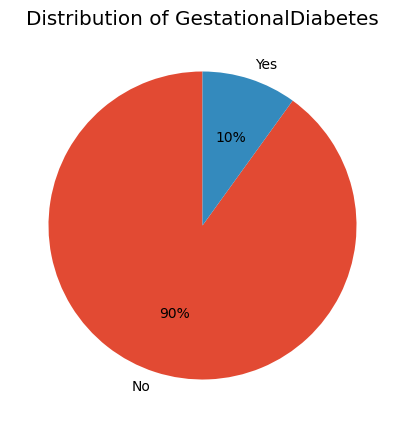

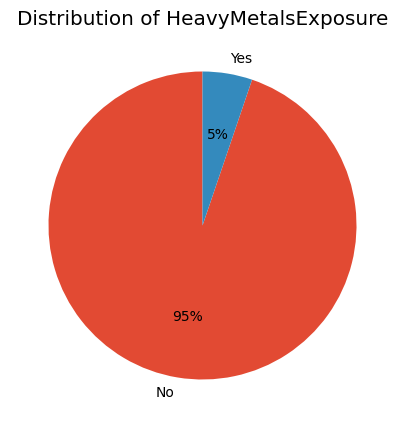

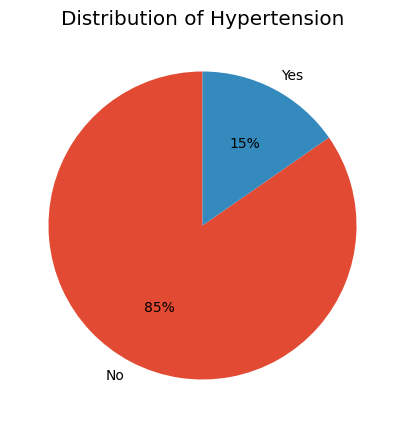

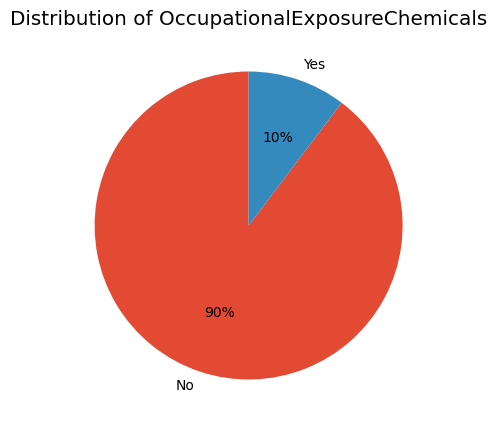

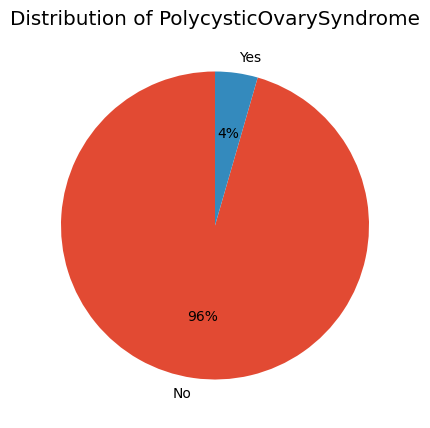

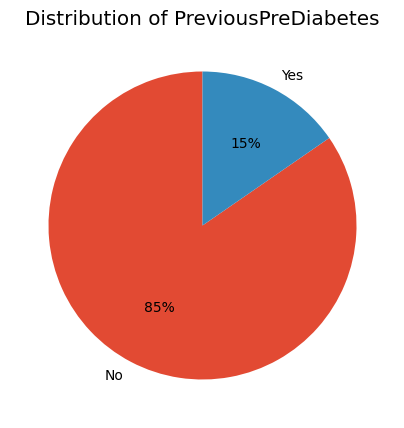

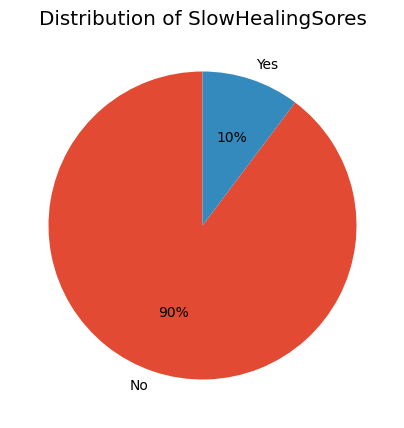

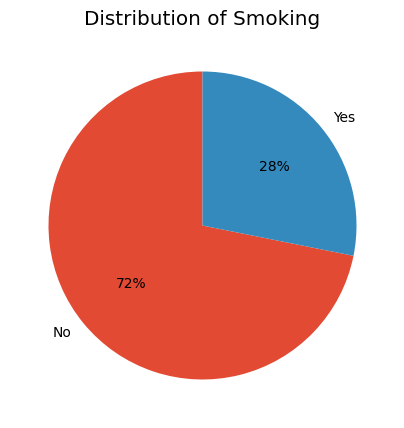

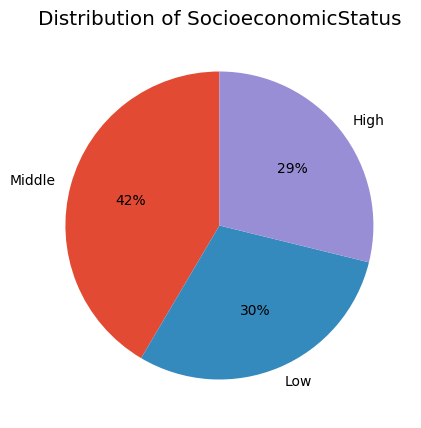

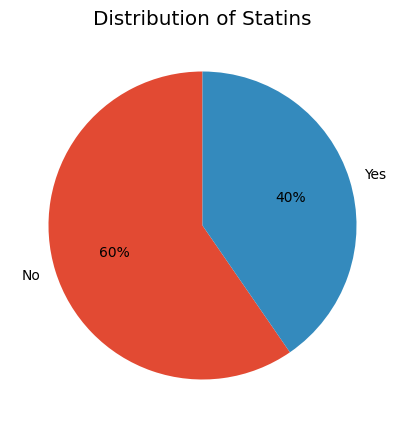

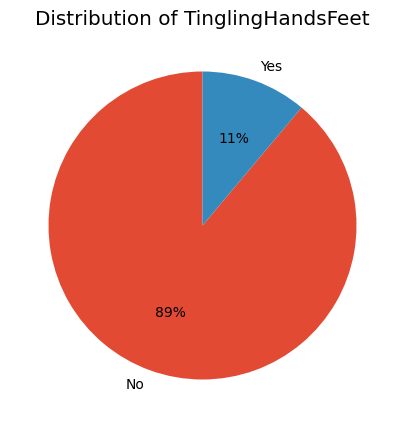

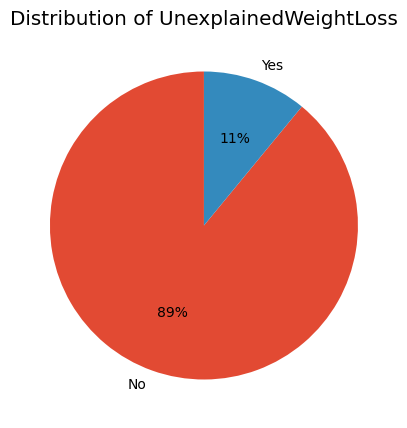

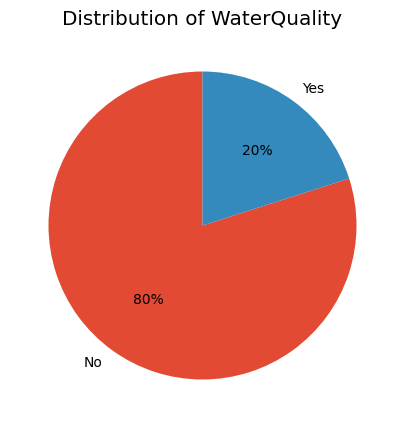

In [19]:
# Distibution plots for the features
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.difference(['DoctorInCharge'])

for i in categorical_columns:
    df[i].value_counts().plot.pie(
        autopct="%1.0f%%",   # show percentages
        figsize=(5,5),    
        startangle=90       # rotate for better readability
    )
    plt.title(f"Distribution of {i}")
    plt.ylabel('')
    plt.show()

C:\Users\Aderoju\AppData\Local\Temp\ipykernel_19976\1688725938.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,5))


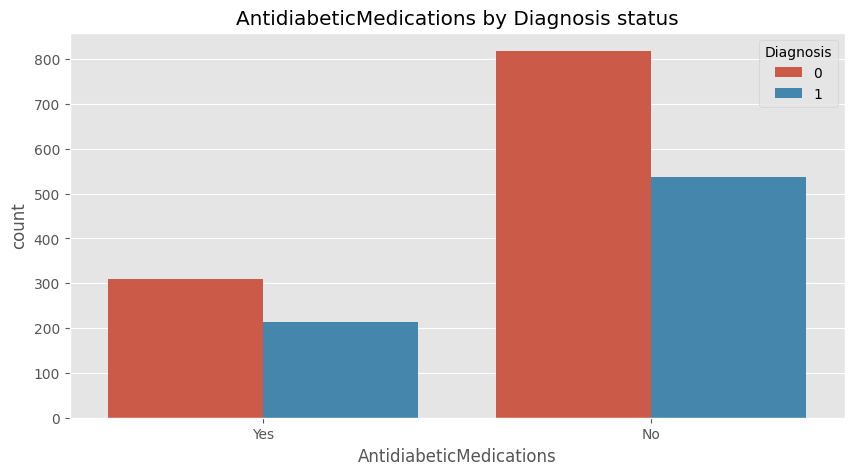

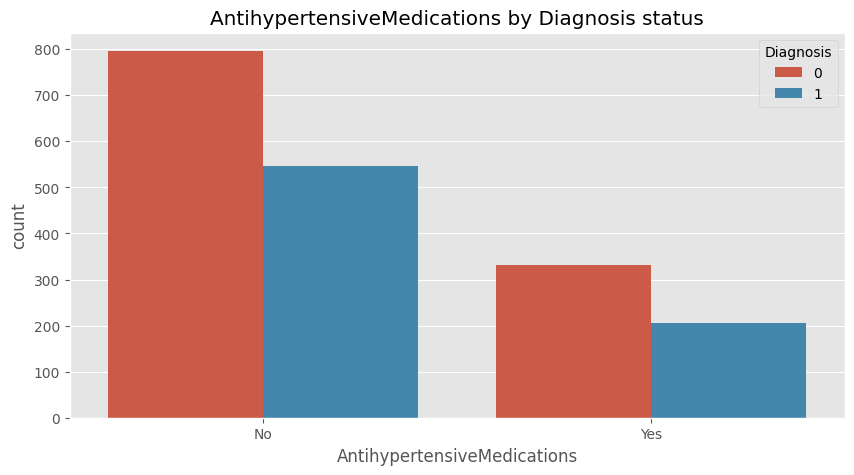

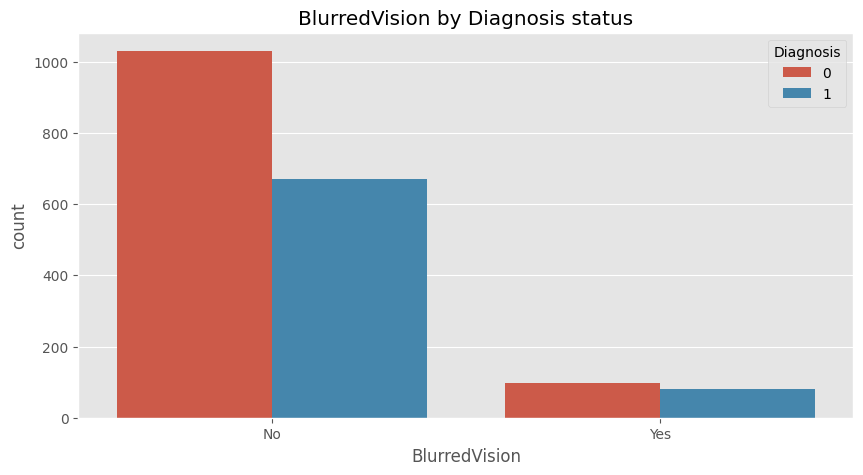

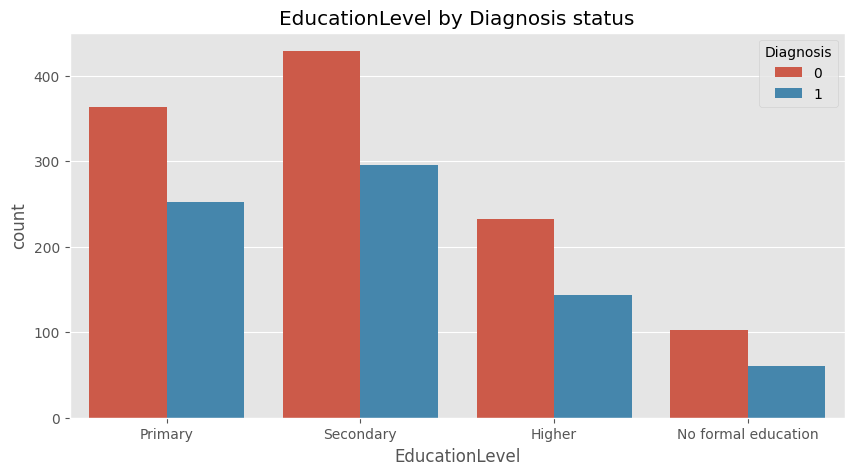

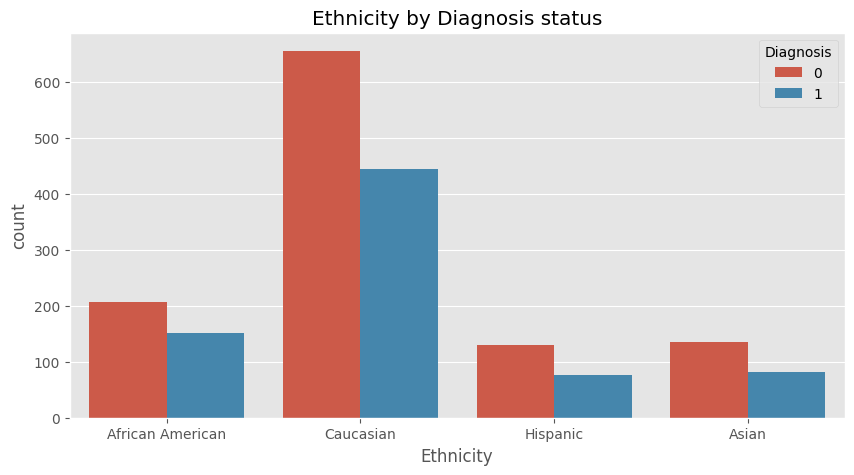

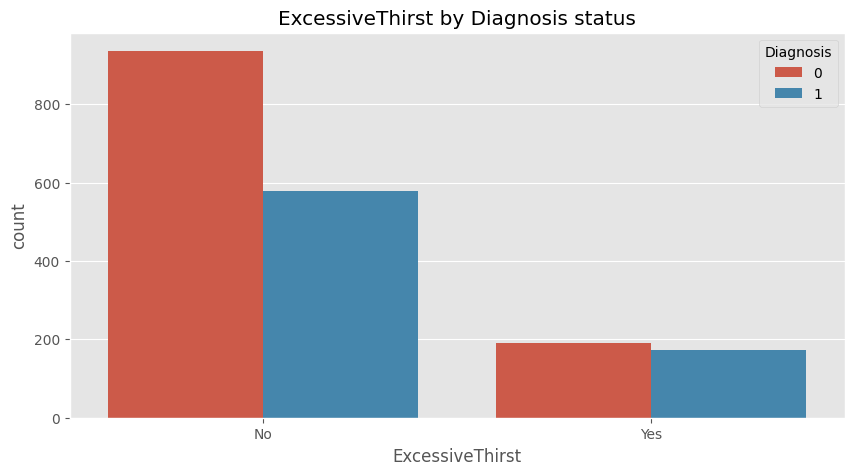

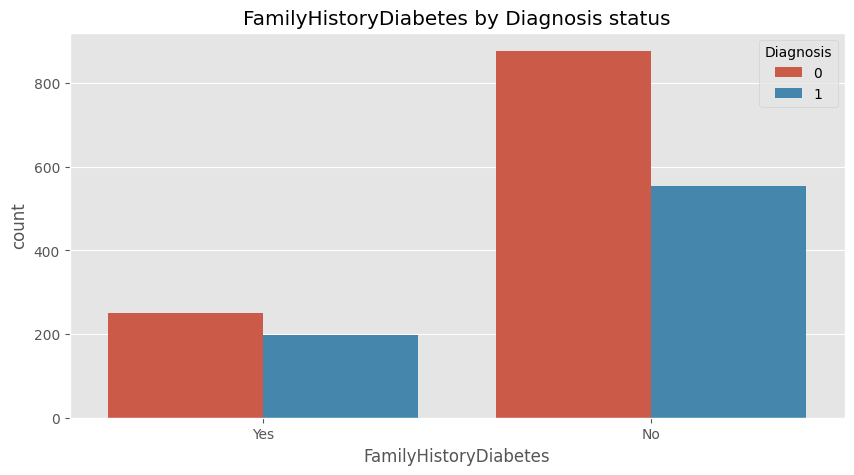

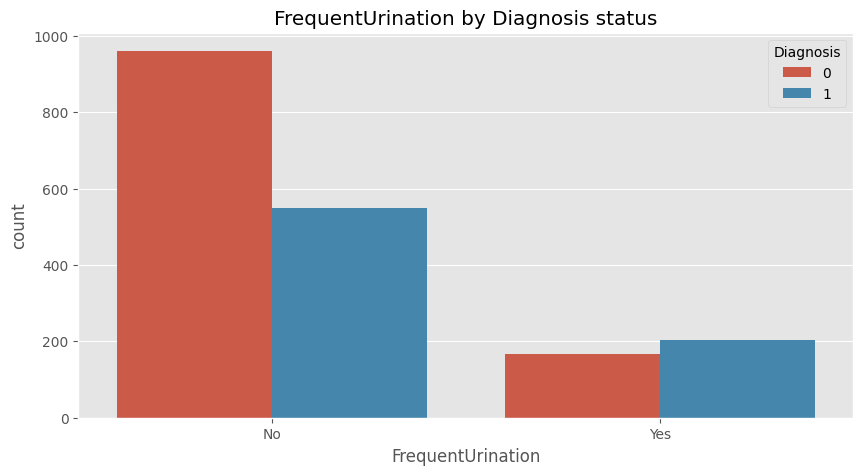

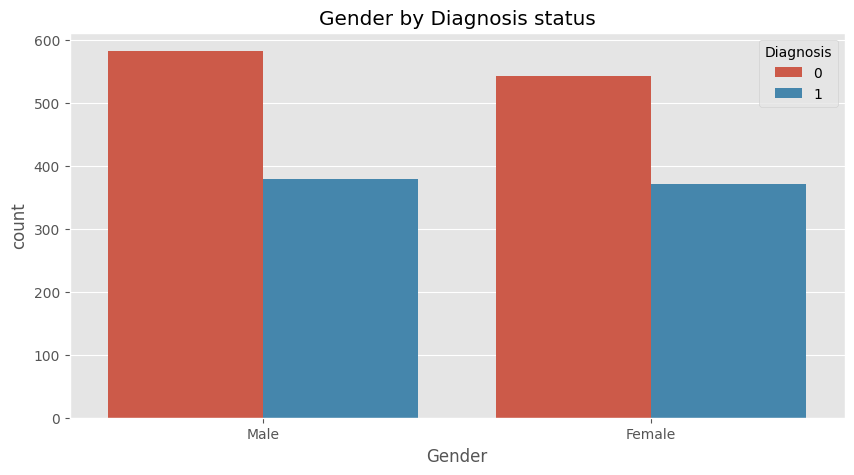

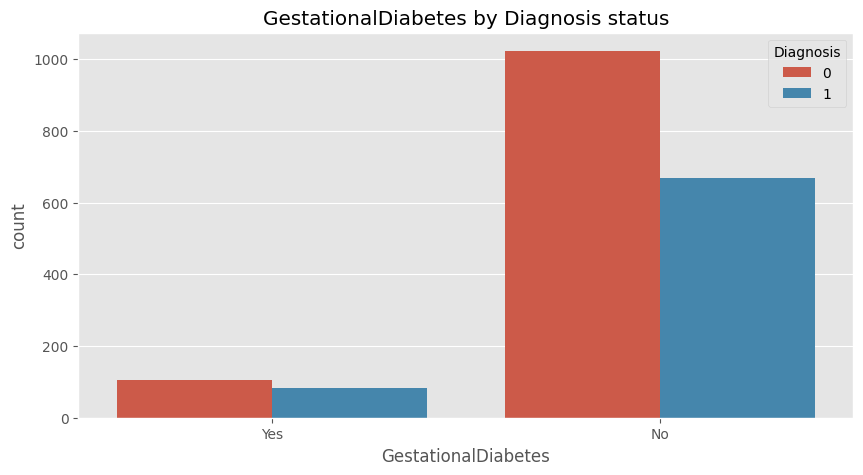

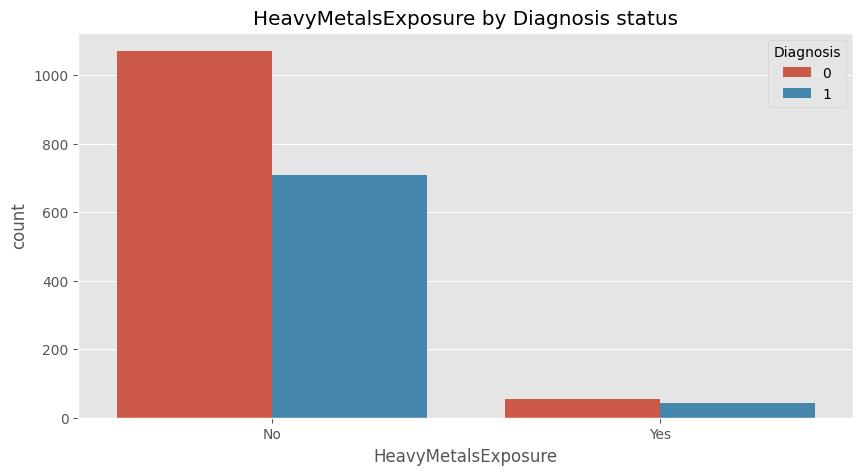

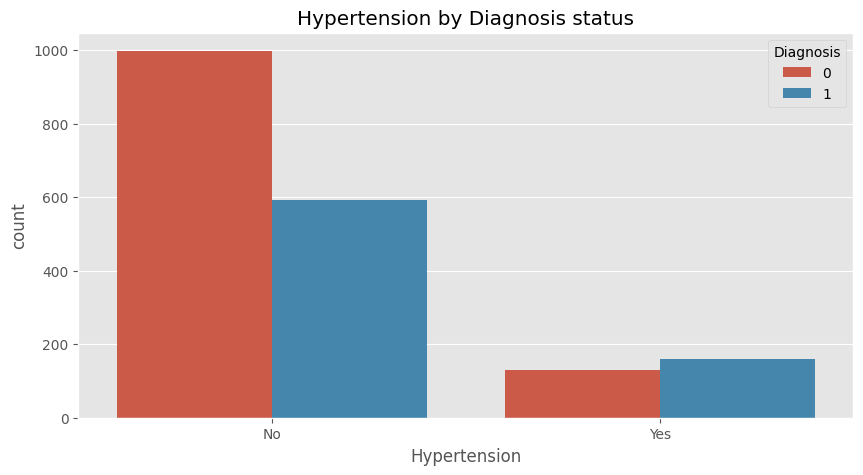

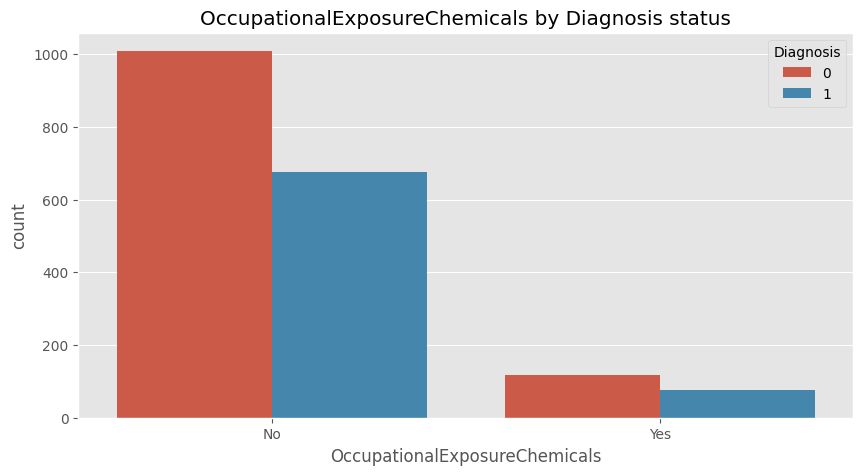

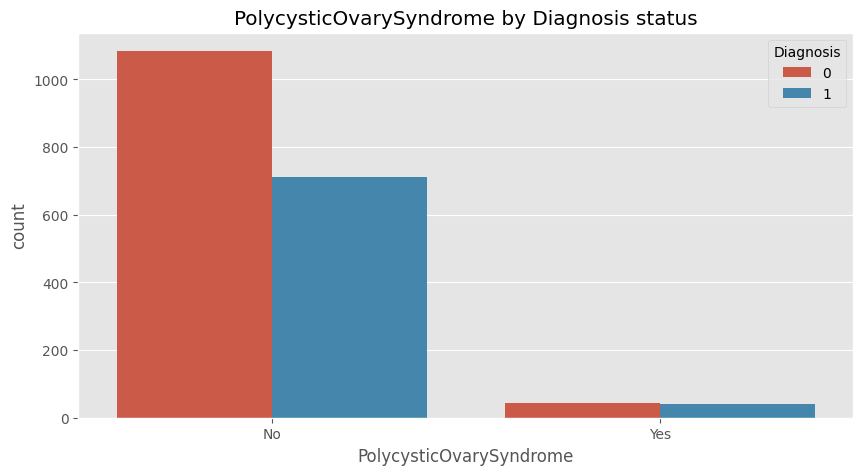

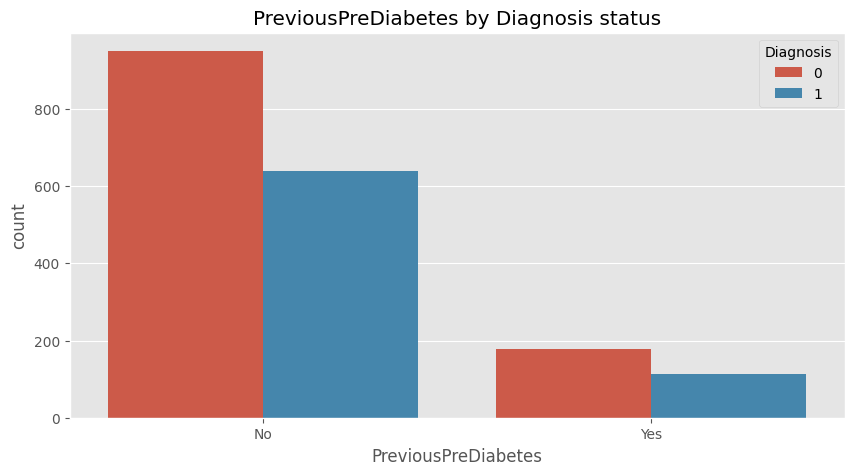

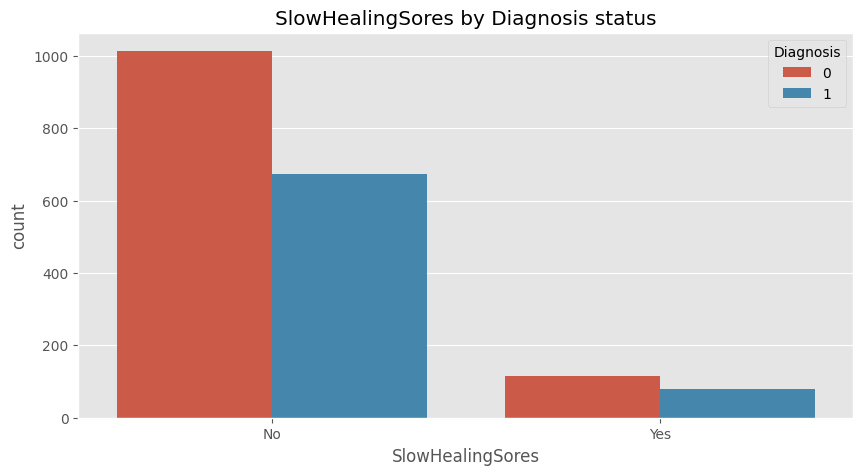

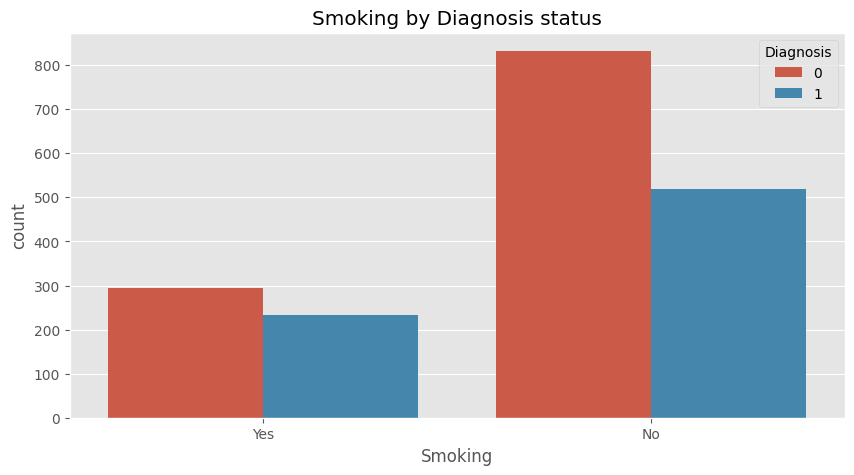

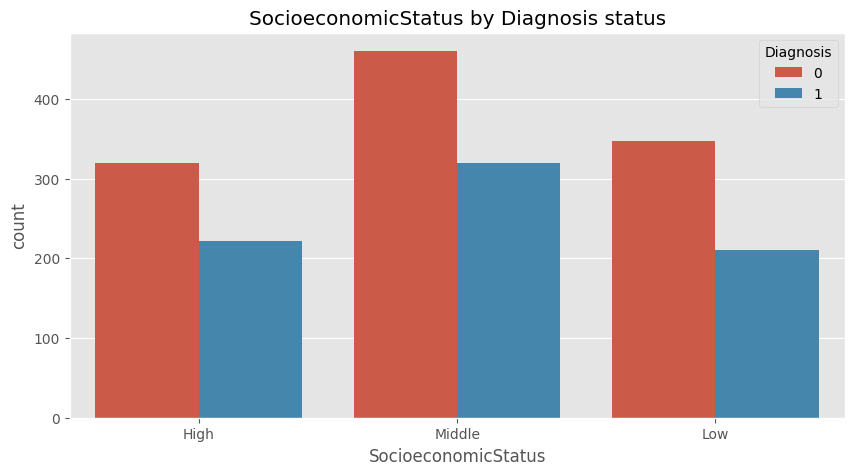

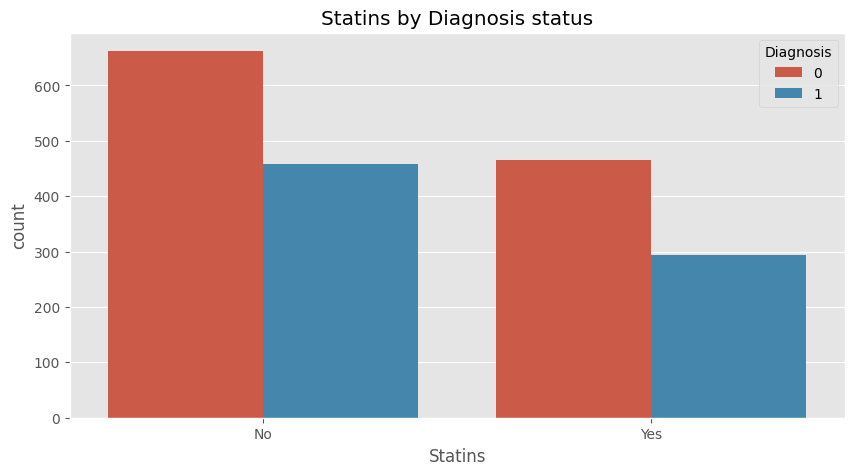

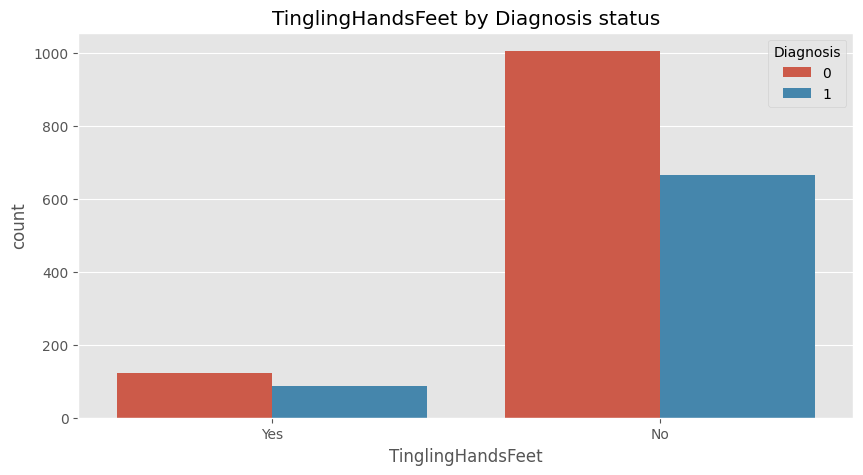

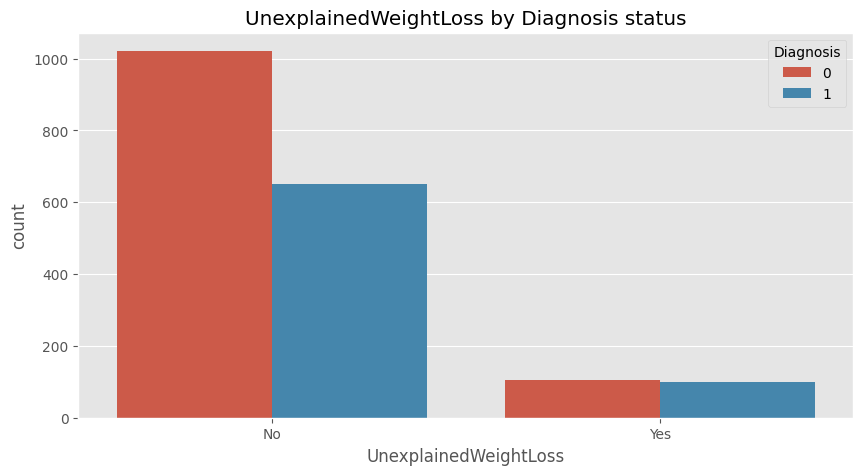

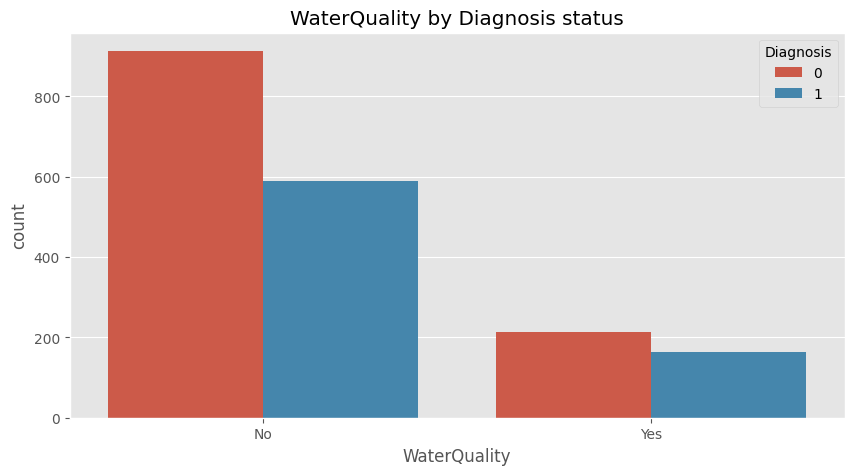

In [20]:
# obtain distribution plot for the categorical feautures against the target column 

# categoric features visualization
data_categoric = df.loc[:, categorical_columns]
for i in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(x = i, data = df, hue=target_column)
    plt.title(f"{i} by {target_column} status")

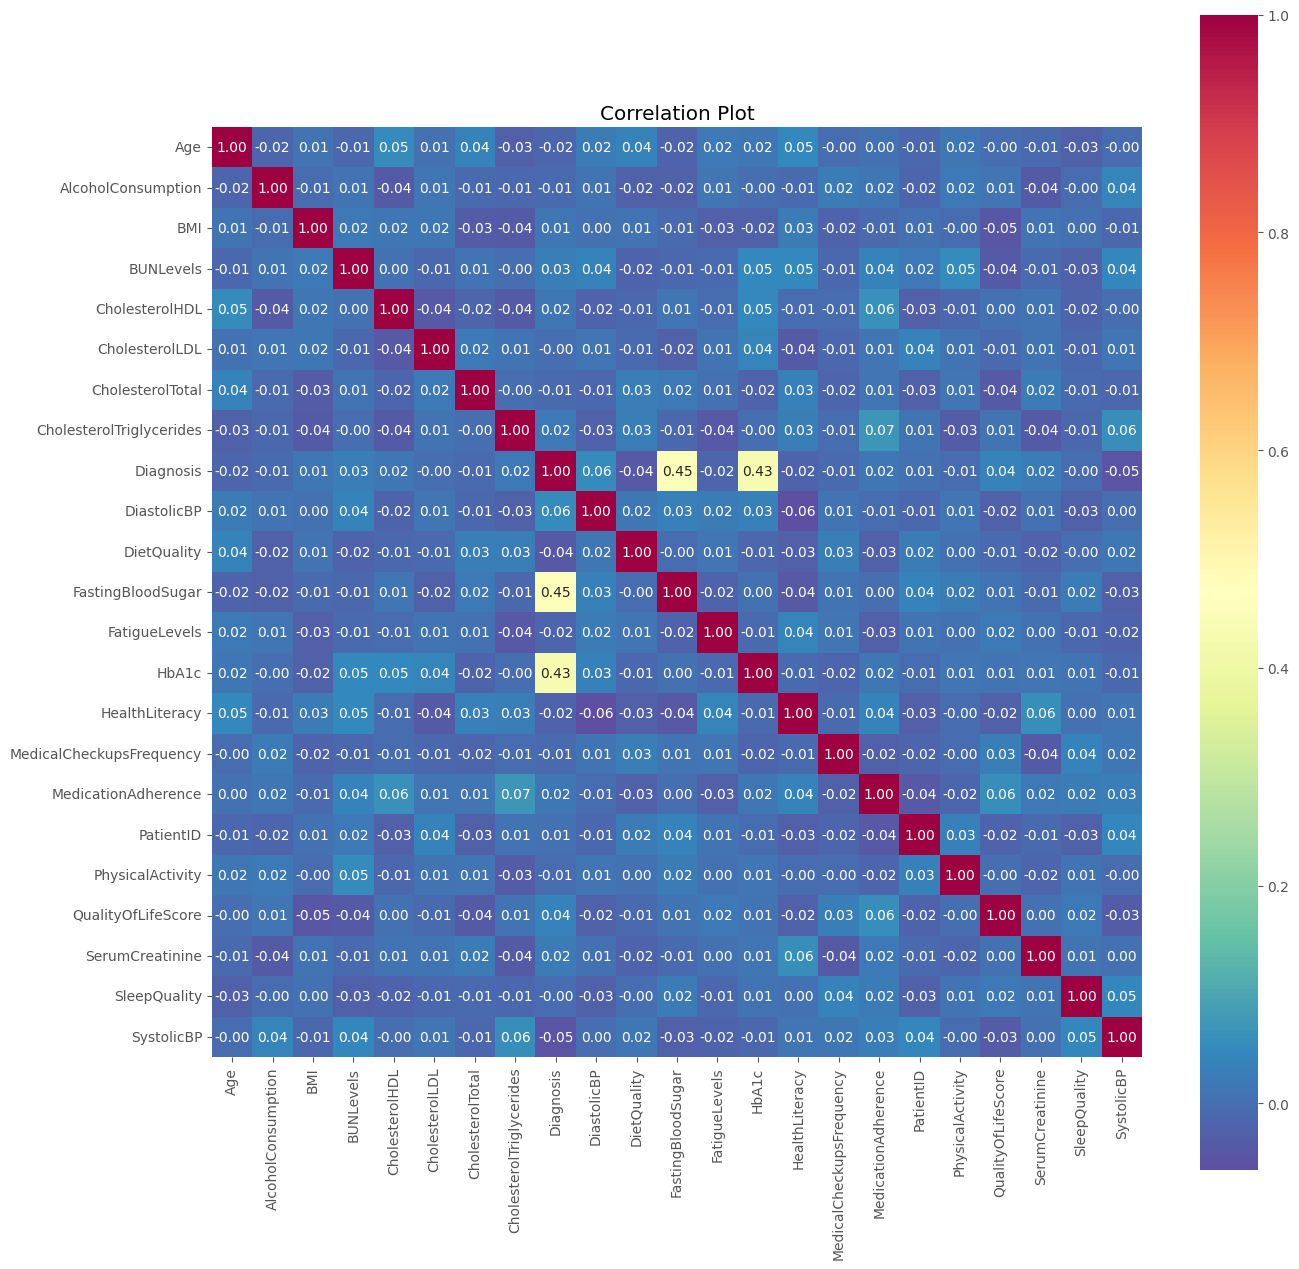

In [21]:
# Obtain Correlation matrix between the numeric features
cormat(df)

### Some Insights from the Dataset

* No duplicated records in the dataset
* Total records in the dataset is 1879, with 46 features.
* No missing records
* Features such as `DoctorInCharge` and `PatientID` are not informative
* Measure of skewness and kurtosis indicate that the dataset is fairly symmetric, and platykurtic.
* No significant outliers observed.
savings_balance,employment_length,personal_status,residence_history,telephone* have missing records.
  - missingness in `checking_balance` could indicate `no checking account`
  - missing data in `savings_balance` could also indicate `no saving account`
  - missing data in `employment_length` could imply the person is `unemployed`.
  - someone without `residence_history` record could be new in the area.
  - missing record for `personal_status` could be due to its sensitivity.
  - missing `telephone` could imply no telephone is registered under the customer’s name"
* The data showed that about 40% of these patients were diagnosed to have diabetes, while 60% with no signicant diabetes.
* The following are significant symptom of diabetes ```Blurred Vision,Excessive Thirst, Family History Diabetes, Frequent Urination,Gestational Diabetes, Heavy Metal Exposure, Hypertension,PolycysticOvarySyndrome, Slow Healing Sores, Smoking,Unexplained Weight Loss,```
* Defaulters in the dataset tend to have borrowed larger loan amounts on average compared to non-defaulters. This suggests that higher loan amounts may be associated with increased risk of default, although this effect could be influenced by other factors such as income and loan tenor.
* Both checking and savings balances exhibit similar patterns with respect to default risk. Customers with lower account balances are more likely to default, suggesting that limited liquidity and weaker financial buffers increase repayment risk.
* There are about 58% caucasian in the dataset, while other ethnic groups shared the remaining 42%, which suggests a potential systematic bias towards ethnic groups.
The gender groups are roughly equally distributed
* There's no significant correlations among the numeric features, except between Diagnostic and Hb1aC(r=0.43) and Fasting blood sugar (r=0.45).

### Strategies to Address Issues in the Dataset

* **Imbalance dataset**: The dataset is moderately imbalanced, with 40% diabetic patients and 60% non-diabetic. To address this and improve model generalization, the SMOTE (Synthetic Minority Over-sampling Technique) will be applied to create synthetic samples of the minority class.
* **Exclusion of Sensitive/redundant features**:
    - `gender` and `ethnicity` will be excluded, as they are protected attributesc in most jurisdictions and may introduce bias or discriminatory outcomes. Nevertheless, fairness assessment will be conducted to validate the model’s behavior with respect to these attributes.
* **Outliers**: `RobustScaler` will be used to handle the outlying points gracefully, couple with the fact that tree-based models are robust to outliers.

**Note: Most of these strategies will be carried out during data preprocessing and model pipeline development** 



### Data Preprocessing

In this section, the following will be done
- The dataset will be split into training and testing datasets (using 80:20)
- Sensitive/redundant features (gender,telephone,foreign_worker,dependents,tenor) will be removed from the training and testing data

In [9]:
# Set the output folder for training and testing dataset, as well as the test dataset size
output_dir = "./processed_data"
test_size = 0.20

In [10]:
# The custom `preprocess_data` function achieve all of these at a go
preprocess_data(df, target_column, output_dir,test_size)

Datasets saved to ./processed_data


In [6]:
# Load the datasets
X_train = load_data("./processed_data/X_train.csv")
X_test = load_data("./processed_data/X_test.csv")

y_train = load_data("./processed_data/y_train.csv")
y_test = load_data("./processed_data/y_test.csv")

protected_feature_train = load_data("./processed_data/protected_train.csv")
protected_feature_test = load_data("./processed_data/protected_test.csv")

In [6]:
# Check the datasets
X_train.shape, X_test.shape

((1503, 41), (376, 41))

In [33]:
y_train.shape, y_test.shape

((1503, 1), (376, 1))

In [34]:
protected_feature_train.shape, protected_feature_test.shape

((1503, 2), (376, 2))

### Model Training And Evaluation

In this section, a unified pipeline that will handle the following was developed.

* **Features Engineering**
   * Introduce polinomial features for all the continuous variables
* **Dataset imbalance**: addressed using SMOTE to generate synthetic samples for the minority class ("bad" credit risk) during model training.
* **Data Normalization**
  - Standardization for numerics
  - OneHotEncoding for categorical variables (Nominal)
  - LabelEncoding for categorical variables (Ordinal)
* **Model training & Evaluation**
  - Trained three models Random Forest, XGBoost, Logistic Regression
  - Handled **overfitting** based on Feature importance selection
  - Evalaute model performance on test datasets

In [7]:
# Train all the models using the pre-defined pipeline, and return the performance metrics
train_and_evaluate_model(X_train, y_train)

Model: logistic
Validation Performance
ROC AUC: 0.90
Precision: 0.77
Recall: 0.82
f1: 0.79
Accuracy: 0.83


Training Performance
ROC AUC: 0.92
Precision: 0.79
Recall: 0.84
f1: 0.81
Accuracy: 0.85


Model: rf
Validation Performance
ROC AUC: 0.95
Precision: 0.93
Recall: 0.87
f1: 0.90
Accuracy: 0.91


Training Performance
ROC AUC: 0.97
Precision: 0.94
Recall: 0.90
f1: 0.92
Accuracy: 0.93


Model: xgb
Validation Performance
ROC AUC: 0.94
Precision: 0.93
Recall: 0.87
f1: 0.90
Accuracy: 0.91


Training Performance
ROC AUC: 1.00
Precision: 1.00
Recall: 1.00
f1: 1.00
Accuracy: 1.00




#### Key Observations

1 Logistic Regression:

- Training and Validation ROC-AUC is 90-92%, which indicates no overfitting.

2 Random Forest:

- Training and validation ROC-AUC 95%-97%, indicating good generalization.

2 XGBoost:

- Training ROC-AUC ~1.00 and validation ROC-AUC ~0.95, indicating bad generalization.


Overall, Random Forest had the most stable performance of the 3 models


### Model Hyperparameter Tuning 

Here we will use 5-fold stratified sampling to get more reliable metrics rather than relying on a single training/testing split, to assess generalization of the models.

In [8]:
# Cross_validate the models, and return the best among the competing models

model_tuning(X_train,y_train)

logistic: 0.7747391550007185
rf: 0.9437289562289563
xgb: 0.9434294161808523

Best Model: rf | Score: 0.9437289562289563


### Tuned Model Performance

In [10]:
model_grid = {'Logistic':load_model(r".\model\cv_logistic.pkl"),
              'Random Forest':load_model(r".\model\cv_rf.pkl"),
              'XGBoost':load_model(r".\model\cv_xgb.pkl")}

Logistic Performance
Accuracy: 0.81
Precision: 0.75
Recall: 0.81
F1 Score: 0.78
ROC AUC: 0.91




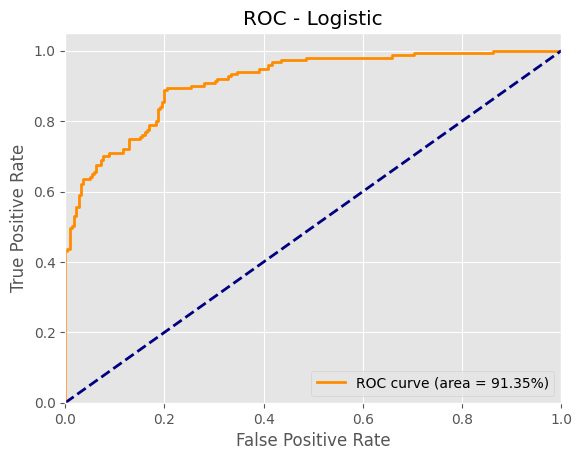

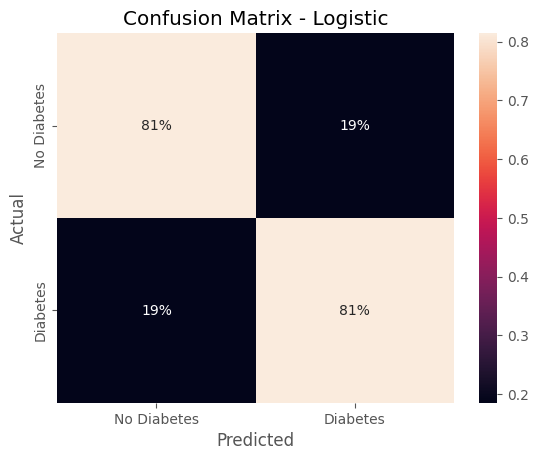

Classification Report for Logistic:

              precision    recall  f1-score   support

           0       0.87      0.81      0.84       225
           1       0.75      0.81      0.78       151

    accuracy                           0.81       376
   macro avg       0.81      0.81      0.81       376
weighted avg       0.82      0.81      0.81       376

Random Forest Performance
Accuracy: 0.93
Precision: 0.96
Recall: 0.85
F1 Score: 0.90
ROC AUC: 0.97




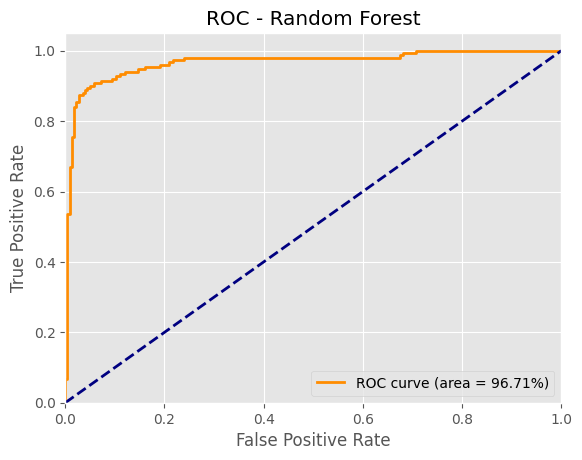

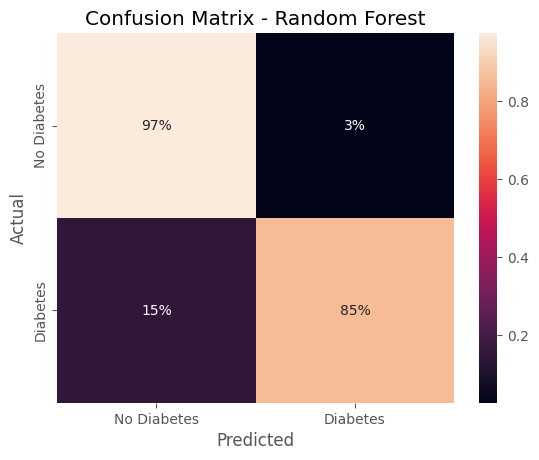

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       225
           1       0.96      0.85      0.90       151

    accuracy                           0.93       376
   macro avg       0.93      0.91      0.92       376
weighted avg       0.93      0.93      0.92       376

XGBoost Performance
Accuracy: 0.94
Precision: 0.96
Recall: 0.88
F1 Score: 0.92
ROC AUC: 0.97




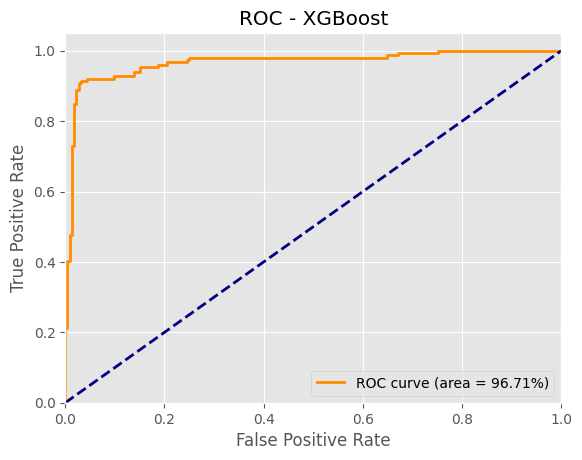

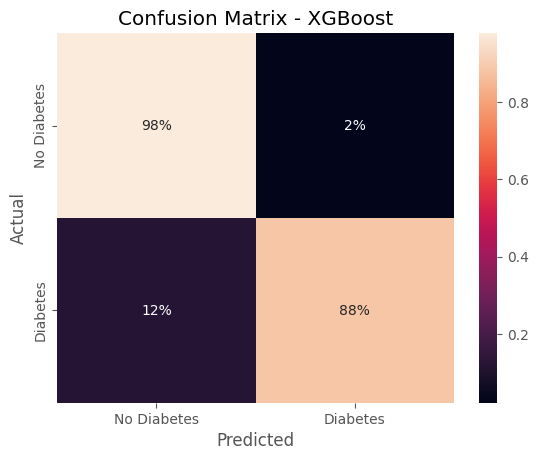

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       225
           1       0.96      0.88      0.92       151

    accuracy                           0.94       376
   macro avg       0.94      0.93      0.94       376
weighted avg       0.94      0.94      0.94       376



In [12]:
for name, pipeline in model_grid.items():
    evaluate_performance(pipeline,name,X_test,y_test)

### Fairness Check

Here we will do fairness check for gender, and ethnicity to ascertain, model fairness irrespective of these categories 

In [18]:
# Fairness Check
for col in protected_feature_test.columns:
    # Group sizes
    sensitive = protected_feature_test[col]
    group_counts = sensitive.value_counts()
    for name ,pipeline in model_grid.items():

        # First obtain prediction for testing dataset using the model
        y_pred = pipeline.predict(X_test)
        print(f"Fairness Check for {name} - {col}")
        print("\n Group sizes:\n", group_counts)
        print()
        fairness_check(y_test,y_pred,sensitive)
        print()

Fairness Check for Logistic - Gender

 Group sizes:
 Gender
Male      202
Female    174
Name: count, dtype: int64


 Performance by group:

        accuracy  selection_rate       tpr       fpr
Gender                                              
Female  0.798851        0.419540  0.806452  0.205357
Male    0.826733        0.455446  0.820225  0.168142

 Fairness metrics:
Demographic parity difference: 0.04
Demographic parity ratio: 0.92
Equalized odds difference: 0.04

 Interpretation:
 Demographic parity: acceptable
Equalized odds: acceptable

Fairness Check for Random Forest - Gender

 Group sizes:
 Gender
Male      202
Female    174
Name: count, dtype: int64


 Performance by group:

        accuracy  selection_rate       tpr       fpr
Gender                                              
Female  0.908046        0.321839  0.822581  0.044643
Male    0.940594        0.391089  0.876404  0.008850

 Fairness metrics:
Demographic parity difference: 0.07
Demographic parity ratio: 0.82
Equaliz

### Interpretation

* Gender - all the models achieved the best fairness perfromance.
* Ethinicity - there seems to be some amount of disparity across different groups and models. However, the
XGBoost model exhibited the most severe disparity.

### Model Selection

In terms of predictive performance, both Random Forest and XGBoost achieved comparable results across the evaluated metrics, indicating that neither model has a clear advantage in overall accuracy or discrimination.

However, when fairness is considered, particularly across the defined sensitive groups, the Random Forest model demonstrates more balanced outcomes, with lower disparities in key fairness metrics such as demographic parity and equalized odds.

Therefore, while both models are similarly effective from a performance standpoint, Random Forest provides a better trade-off between accuracy and fairness, making it the more suitable choice for predicting diabetic status in this context.

In [19]:
best_model_name = 'Random Forest'
pipeline = model_grid[best_model_name]


### Feature Importance

Next, we will look at the importance of the features in the dataset to predicting diabetic status, as well as the direction of their effects on prediction.


In [20]:
# Get transformed feature names
feature_names = pipeline[:-1].get_feature_names_out()

# Now align importances
model = pipeline.named_steps['classifier']   # obtain the model object from the pipeline

# store the importances in a dataframe
if 'logistic' in best_model_name.lower():
    importances = pd.Series(
        model.coef_[0], 
        index=feature_names
    ).sort_values(key=abs, ascending=False)
else:
    importances = pd.Series(model.feature_importances_, index=feature_names)


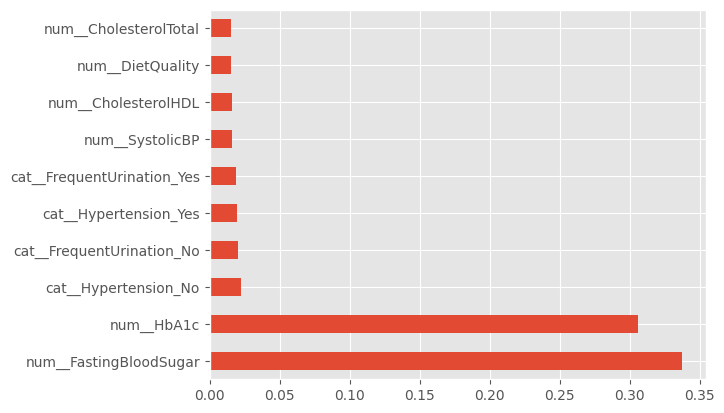

In [25]:
#plot the importance of the most contributing features
importances.nlargest(10).plot(kind='barh')
plt.show()

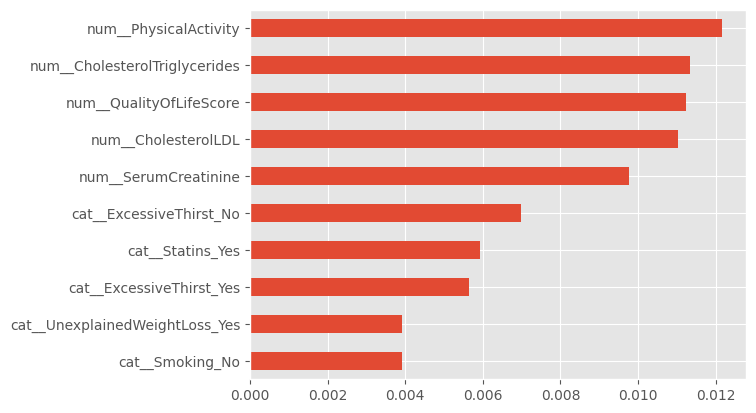

In [22]:
#plot the importance of the least contributing features
importances.nsmallest(10).plot(kind='barh')
plt.show()

In [23]:
# Transform test features
X_transformed = pipeline[:-1].transform(X_test)

if 'logistic' in best_model_name.lower():
    explainer = shap.LinearExplainer(
    model,
    X_transformed
)

else:
    # Create explainer the model
    explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer(X_transformed)

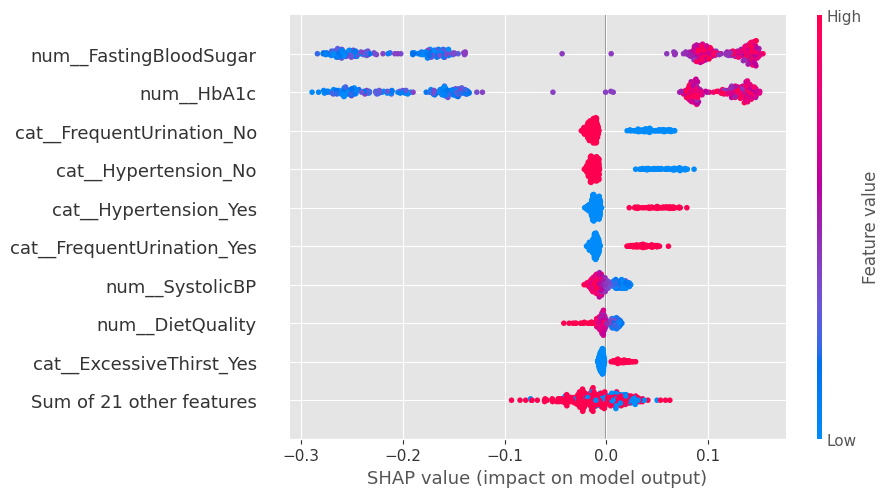

In [24]:
if 'random' in best_model_name.lower():
    shap_values = shap_values[:, :, 1]

shap.plots.beeswarm(shap_values)

### Interpretation

The results from above suggest:
* Blood Sugar, HbA1c, Hypertension, systolicBP, and Excessive, Diet Quality, Cholesterol levels are the most significant factors in predicting diaetic status.
* High Blood Sugar, High HbA1c, Hypertension, Frequent Urination, and Excessive thirst are strong indcators of diabetic.